## Classification

In this notebook, we will introduce the concept of classification and learn how to apply our knowledge of linear regression to address this new machine learning challenge.

In linear regression, we found a relationship between independent variables (inputs) and dependent variables (outputs). The input variables can be continuous (e.g., some measurement from a sensor) or discrete, and the output is a continuous variable. 

Similarly, in classification, we are interested in finding a relationship between independent variables (features) and a dependent variable (classes). However, in this case, the classes must be a discrete variable with just two or a few potential values. 

| feature 1 | feature 2 | Class|
|--|--|--|
|0.25 | 0.13| 0|
|0.45 | 0.23| 0|
|0.12 | 0.98| 1|
|0.35 | 0.16| 0|
|0.05 | 0.74| 1|
|0.36 | 0.08| 0|


The objective of the classification problem is to identify the relationship between the features and the classes, such that when new features are available, it is possible to predict the class.

| feature 1 | feature 2 | Class|
|--|--|--|
|0.07 | 0.78| ?|

Note that the class can be a category (i.e., pertencence to a group such as SEX (M, class=0, F, class=1), or disease (Healhy, class=0, patient,  class=1)) or can be derived by grouping continous variables (i.e, groups created from age, such as young (age <18, class=0),  adult (age >=18 and <60, class==1), older adult (<=60, class==2))

When you have just two or three features, it is possible to visualize your data.


Text(0, 0.5, 'Feature 2')

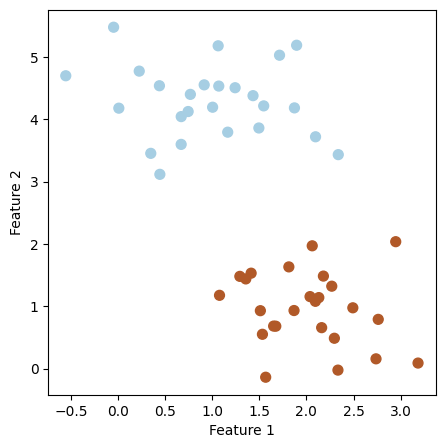

In [129]:
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt


# create 50 separable points
X, y = make_blobs(n_samples=50, centers=2,
                  random_state=0, cluster_std=0.60)

# plot the data
fig, ax = plt.subplots(figsize=(5, 5))
point_style = dict(cmap='Paired', s=50)
ax.scatter(X[:, 0], X[:, 1], c=y, **point_style)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

Here we have two-dimensional data: that is, we have two features for each point, represented by the $(x,y)$ positions of the points on the plane. In addition, we have one of two class labels for each point (class 0 -> Blue, class 1 -> Brown). 

From these features and labels, we would like to create a model that will help us decide whether a new point should be labeled "blue" or "brown."

Text(0, 0.5, 'Feature 2')

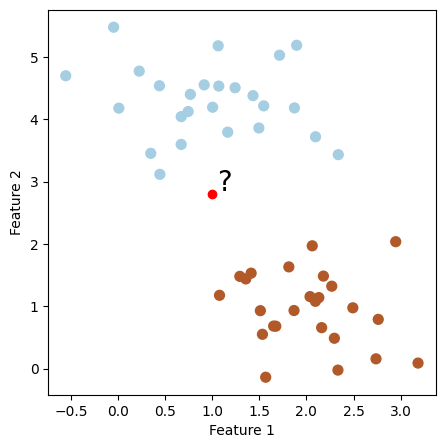

In [130]:
#now, if we have a new datapoint, how do we determine the class?
# plot the data
fig, ax = plt.subplots(figsize=(5, 5))
point_style = dict(cmap='Paired', s=50)
ax.scatter(X[:, 0], X[:, 1], c=y, **point_style)
ax.scatter(1,2.8,c='red')
ax.text(1.05,2.85,'?', fontsize=20)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

There are a number of possible models for such a classification task. We will use an extremely simple one. We will make the assumption that the two groups can be separated by drawing a straight line through the plane between them, such that points on each side of the line fall in the same group. 

Here, the model is a quantitative version of the statement "a straight line separates the classes". The objective is then to use the data to learn the intercept and slope of this line and use it to make predictions about new data points. At the end, the optimal values for these model parameters are learned from the data using gradient descent or a related algorithm. 

---
Going back to our linear regression notation, we have that 
$$
\hat{y} = \omega X
$$

where $X$ is the feature matrix and $\omega$ the model parameters (intercept and slope). The model parameters are obtained by comparing  the model predictions ($\hat{y}$) and the classes ($y$).


### The Problem
This is an ill-defined problem. By definition, the classes are discrete (0 or 1 in this case), but the model output ($\hat{y}$) can take any value, either positive or negative. Thus, there is no easy way to compare the model output and the measured classes. 

One potential solution to this problem is to transform the model output so that it becomes 0 or 1 (as the classes). There are many ways to do this (such as using a threshold); however, if we want to use gradient descent for parameter estimation, we need to ensure that we can easily estimate the gradient of the resulting function. 

### The solution 
One reasonable transformation is to use the sigmoid function, which maps any value $x$ into a new value in the range 0 and 1. 
$$
\sigma(x) = \frac{1}{1+e^{-x}}
$$

Text(0.5, 0, 'x')

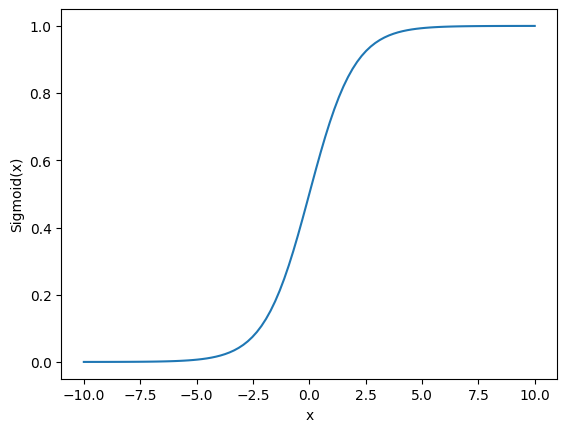

In [127]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

x_sig = np.linspace(-10,10,100)
plt.plot(x_sig, sigmoid(x_sig))
plt.ylabel('Sigmoid(x)')
plt.xlabel('x')

Thus, our new model is 
$$
\hat{y} = \sigma(\omega X)
$$

or

$$
\hat{y} = \frac{1}{1+e^{\omega X}}
$$

Interestingly, by forcing the output to be between 0 and 1, we can interpret the model's output as the probability of belonging to class 1. So, the model does not estimate the class directly; rather, it estimates how likely the feature set is to belong to class 1.  

### Cost Function 
When dealing with linear regression, we used the RMSE as the cost function. This cost function allowed us to find the optimal parameter set that reduces the error between measurements and predictions. We chose that cost function because it was **CONVEX**, allowing us to find the optimal parameters with gradient descent. 

However, when using the RMSE in the classification problem, we obtain
$$
RMSE (\omega) = \frac{1}{2N}\sum(\hat{y} - y)^2 \\
$$

$$
RMSE (\omega) = \frac{1}{2N}\sum( \frac{1}{1+e^{\omega X}} - y)^{2}
$$

This function is no longer convex; thus, we can not use gradient descent to find the optimal parameters.

---

An alternative **CONVEX** cost function is a **logistic loss**. This function has the following form :
$$
L(\boldsymbol{\omega}) = -\frac{1}{m}\sum_{i=1}^{m}\left[y[i]\log(\hat{y}[i]) + (1-y[i])\log(1-\hat{y}[i])\right]
$$

- $y[i]$ is the true class (0 or 1)
- $\hat{y}[i]$ is the model prediction (a number between 0 and 1)

Let us diggest what this formula implies. 
- Case 1: $y[i] = 1$ and $\hat{y}[i] \approx 1$ (**Correct Classification**)
    $$
    \begin{align}
        &(1-y[i]) = 0  \rightarrow (1-y[i])\log(1-\hat{y}[i]) = 0 \\
        &\log(\hat{y}[i]) \approx 0  \rightarrow y[i]\log(\hat{y}[i]) \approx 0  \\
    \end{align}
    $$
    
    $$
    L(\boldsymbol{\omega}) \approx 0 
    $$
    
- Case 2: $y[i] = 0$ and $\hat{y}[i] \approx 0$ (**Correct Classification**)
    $$
    \begin{align}
        &y[i] = 0 \rightarrow y[i]\log(\hat{y}[i]) = 0\\
        &\log(1 - \hat{y}[i]) \approx 0 \rightarrow (1-y[i])\log(1-\hat{y}[i]) \approx 0 \\
    \end{align}
    $$
    
    $$
    L(\boldsymbol{\omega}) \approx 0 
    $$
    
- Case 3: $y[i] = 1$ and $0 < \hat{y}[i] < 1$ (**Incorrect Classification**)

    $$
    \begin{align}
        &y[i] = 1 \rightarrow (1-y[i])\log(1-\hat{y}[i]) = 0\\
        &\log(\hat{y}[i]) < 0 \ \text{becomes closer to 0 as it gets closer to 1}  \\
        &\rightarrow y[i]\log(\hat{y}[i]) < 0 \\
    \end{align}
    $$
    
    $$
    L(\boldsymbol{\omega}) > 0  
    $$
    
- Case 4: $y[i] = 0$ and $0<\hat{y}[i] < 1$ (**Incorrect Classification**)

    $$
    \begin{align}
        &y[i] = 0 \rightarrow y[i]\log(\hat{y}[i]) = 0\\
        &\log(1 - \hat{y}[i]) < 0 \text{becomes closer to 0 as it gets closer to 0} \\
        &\rightarrow (1-y[i])\log(1-\hat{y}[i]) < 0 \\
    \end{align}
    $$
    
    $$
    L(\boldsymbol{\omega}) > 0  
    $$
    
So, the **logistic loss** is non-zero when the prediction model generates a probability that does not agree with the training data.


The goal now is to use this cost function as part of a gradient descent iterative algorithm to find the slope and intercept of our model. An algorithm to estimate these parameters is available as part of the `sklearn` library.

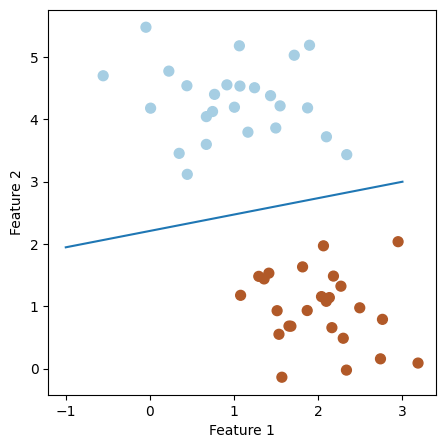

In [131]:
from sklearn.linear_model import LogisticRegression

#fit the model
log_reg = LogisticRegression()
log_reg.fit(X,np.ravel(y))

# plot the data
fig, ax = plt.subplots(figsize=(5, 5))
point_style = dict(cmap='Paired', s=50)
ax.scatter(X[:, 0], X[:, 1], c=y, **point_style)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

#to plot the boundary 
# 2. Extract coefficients
# log_reg.coef_ is a 2D array as there are two features: [[beta1, beta2]]
# log_reg.intercept_ is a 1D array: [beta0]
beta0 = log_reg.intercept_[0]
beta1, beta2 = log_reg.coef_[0]


x_ = np.linspace(-1,3,100)
y_ = -(beta0/beta2 + (beta1/beta2)*x_)
plt.plot(x_,y_)


Now, it is possible to use this model to make predictions to for new data point 
- feature 1 = 1.05
- feature 2 = 2.85

Text(0, 0.5, 'Feature 2')

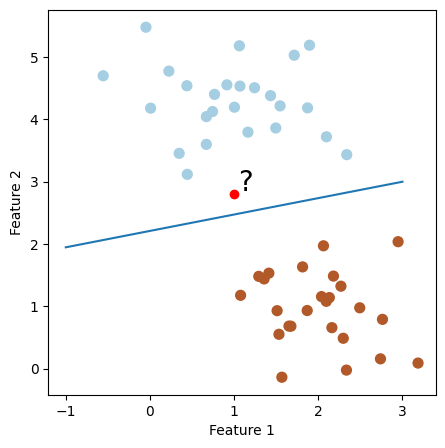

In [132]:
fig, ax = plt.subplots(figsize=(5, 5))
point_style = dict(cmap='Paired', s=50)
ax.scatter(X[:, 0], X[:, 1], c=y, **point_style)

#to plot boundary
plt.plot(x_,y_)
ax.scatter(1,2.8,c='red')
ax.text(1.05,2.85,'?', fontsize=20)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

In [145]:
# We can predict the output of the linear model
output_LinearModel = (beta0 + 1.05*beta1 + beta2*2.85)
print(f'The output of the linear model is = {output_LinearModel}')

# With this output, we can compute the probability of belonging to class 1 (brown), using the sigmoid function
Probability_of_class_1 = (1/(1+np.exp(-output_LinearModel)))
print(f'The probability of class 1 is = {Probability_of_class_1}')

# and the probability of class 0 (blue)
print(f'The probability of class 0 is = {(1-Probability_of_class_1)}')

#and finally, the class, assuming a threshold of 0.5
predicted_class = 1 if Probability_of_class_1 >0.5 else 0
print(f'The predicted class is = {predicted_class}')


The output of the linear model is = -0.7979237551629499
The probability of class 1 is = 0.31046982286416863
The probability of class 0 is = 0.6895301771358313
The predicted class is = 0


You can obtain the same results using pre-built functions

```Python
# We can predict the probability of belonging to either class
prediction_probability = log_reg.predict_proba(np.array([[1.05,2.85]]))
print(f'Probability of belonging to class 1 = {prediction_probability[0][0]*100}%, class 0 = {prediction_probability[0][1]*100}%')

# or we can predict the class directly, assuming a threshold of 0.5
prediction_class = log_reg.predict(np.array([[1.05,2.85]]))
print(f'The predicted class is = {prediction_class[0]}')

```


## Activity

Compute the probabilities for the following input values :
- [1.5, 4.5]
- [2.5, 1]
- [2.499,2.865]

What differences do you notice? 
Hint -> draw the point, see its location relative to the boundary line

## Multiclass Classification

Logistic regression can be naturally extended to more than two classes. The loss function can be expressed as

$$
L(\boldsymbol \omega) = -\frac{1}{N}\sum_{k}\sum_{i}y_{k}[i]\log(\hat{y}_{k}[i])
$$

Where $k$ is the number of classes, $N$ is the number of samples, $y_{k}[i]$ is the target, $\hat{y}_{k}[i]$ is the predicted probability, and $\boldsymbol \omega$ are the model parameters. 

Note that when $y_{k}[i]$ is 1 (or 0) and  $\hat{y}_{k}[i]$ is close to 1 (or 0), the loss is close to zero. However, when $y_{k}[i]$ is 1 (or 0) and $\hat{y}_{k}[i]$ is close to 0 (or 1), the loss function is large. 

In the multiclass problem, the probability has to be computed with a modified formula
$$
\hat{y}_{k}[i] = \sigma(X\boldsymbol{\omega_{k}}) = \frac{\exp(X\boldsymbol{\omega_{k}})}{\sum_{j=1}^{K}\exp(X\boldsymbol{\omega_{j}})}
$$

where each class $j$ has its own set of parameters $\boldsymbol{\omega_{j}}$

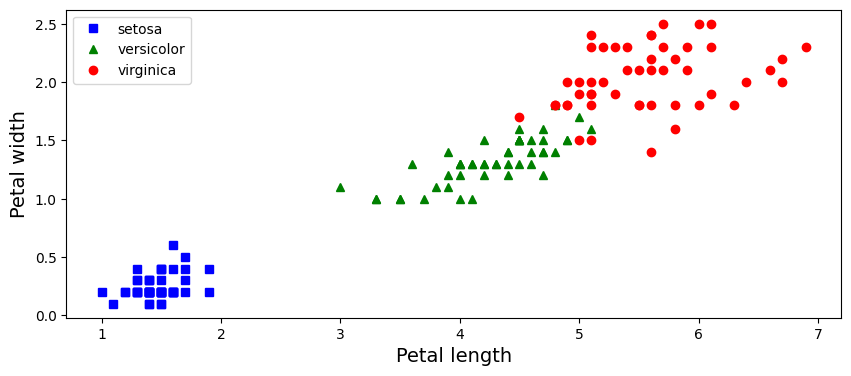

In [117]:
# Example

import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

#load the Iris dataset, a famous dataset for multiclass classification
iris = datasets.load_iris()
X = iris['data'][:,2:] #only two features
y = (iris['target']).astype(int)

plt.figure(figsize=(10, 4))
plt.plot(X[y==0, 0], X[y==0, 1], "bs", label = 'setosa')
plt.plot(X[y==1, 0], X[y==1, 1], "g^", label='versicolor')
plt.plot(X[y==2, 0], X[y==2, 1], "ro", label = 'virginica')
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.legend()
plt.show();

In [126]:
random_seed = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.15,random_state=random_seed)

log_reg = LogisticRegression();
log_reg.fit(X_train,y_train);

#for each element in the test set, check the true class and the predicted probabilities
test_pred_proba = log_reg.predict_proba(X_test)
for idx, results in enumerate(test_pred_proba):

    
    print(f'Petal length = {X_train[idx,0]}, Petal width = {X_train[idx,1]}')
    print(f'True class = {y_test[idx]}')
    print(f'Predicted Probability Class 0 = {results[0]*100}%')
    print(f'Predicted Probability Class 1 = {results[1]*100}%')
    print(f'Predicted Probability Class 2 = {results[2]*100}%')

    print('-----------')
    
    


Petal length = 5.6, Petal width = 2.1
True class = 1
Predicted Probability Class 0 = 0.3465911863730009%
Predicted Probability Class 1 = 83.23240988881427%
Predicted Probability Class 2 = 16.42099892481271%
-----------
Petal length = 6.4, Petal width = 2.0
True class = 0
Predicted Probability Class 0 = 94.67169608557856%
Predicted Probability Class 1 = 5.328249130033182%
Predicted Probability Class 2 = 5.478438827481407e-05%
-----------
Petal length = 5.2, Petal width = 2.3
True class = 2
Predicted Probability Class 0 = 8.961827204507563e-07%
Predicted Probability Class 1 = 0.11468945409481565%
Predicted Probability Class 2 = 99.88530964972247%
-----------
Petal length = 5.8, Petal width = 1.8
True class = 1
Predicted Probability Class 0 = 0.5066210695307733%
Predicted Probability Class 1 = 78.70123326379182%
Predicted Probability Class 2 = 20.792145666677406%
-----------
Petal length = 5.9, Petal width = 2.3
True class = 1
Predicted Probability Class 0 = 0.20777674596078663%
Predicted